# Libraries

In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration

In [27]:
BASE_DIR = 'eval/xquad_xlmr'

# Visualization

In [ ]:
# Dynamically get all metrics.csv files
csv_paths = sorted(Path(BASE_DIR).glob('**/metrics.csv'))
csv_paths = [str(p) for p in csv_paths] # make string paths
print(f"CSV paths: {csv_paths}")

CSV paths: ['eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-en-LoRA-Merged-v260623145250/metrics.csv', 'eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-vi-LoRA-Addition-v260710174202/metrics.csv']


In [ ]:
# Read the CSV files and concatenate them into a single DataFrame
df = pd.concat([pd.read_csv(p) for p in csv_paths], 
               keys=csv_paths, 
               names=['csv_path', None]).reset_index(level=0)

# Add a new column 'model' to the DataFrame by extracting the model name from the CSV path
df['model'] = df['csv_path'].apply(lambda p: os.path.basename(os.path.dirname(p)))

# Display the first few rows of the DataFrame to verify the data
df.head()

,csv_path,lang,test_loss,test_exact_match,test_f1,test_model_preparation_time,test_runtime,test_samples_per_second,test_steps_per_second,model
0,eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-en-...,en,1.583714,55.2,61.714345,0.0034,2.2300,56.054,3.587,XLM-R-Base-squad-en-LoRA-Merged-v260623145250
1,eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-en-...,ar,1.962482,36.0,41.206267,0.0034,2.3110,54.089,3.462,XLM-R-Base-squad-en-LoRA-Merged-v260623145250
2,eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-en-...,de,1.888464,37.6,50.707453,0.0034,2.2370,55.877,3.576,XLM-R-Base-squad-en-LoRA-Merged-v260623145250
3,eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-en-...,el,1.854421,40.0,48.900671,0.0034,2.9096,42.961,2.750,XLM-R-Base-squad-en-LoRA-Merged-v260623145250
4,eval/xquad_xlmr/alxxtexxr/XLM-R-Base-squad-en-...,es,1.736764,44.0,50.395032,0.0034,2.4033,52.012,3.329,XLM-R-Base-squad-en-LoRA-Merged-v260623145250


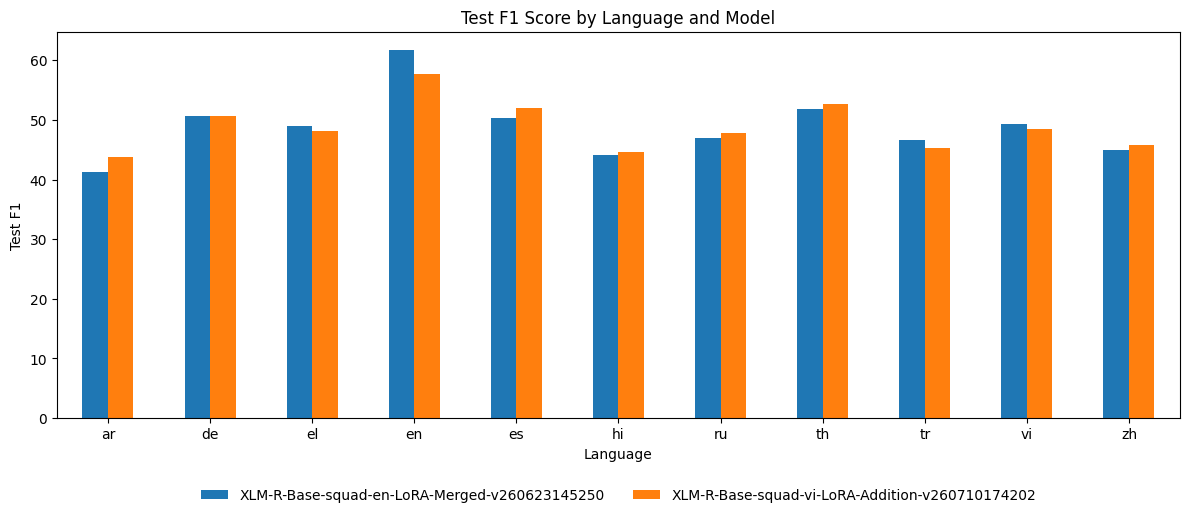

In [32]:
# Plot with pandas pivot table
pivot = df.pivot(index='lang', columns='model', values='test_f1')
ax = pivot.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Test F1 Score by Language and Model')
plt.ylabel('Test F1')
plt.xlabel('Language')

# Move the legend below the plot, centered
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),    # (x, y) in axes coordinates; negative y pushes it below
    ncol=2,                         # two columns if you want to save horizontal space
    frameon=False,                  # optional: cleaner look without border
)

# Adjust the layout to make room for the legend
plt.tight_layout(rect=[0, 0.1, 1, 1])   # leave 10% of figure height at the bottom
plt.show()